<div style="display:inline-block;vertical-align:top;">
<img src= "https://urosario.edu.co/static/getmedia/4b482c72-87c2-49a5-8e81-14312e6270f0/logo-Medicina_Mesa-de-trabajo-1" width=500>


</div>

# **Seminario Tendencias de la Inteligencia Artificial en Salud**
## ***Machine Learning* (ML) para Aplicaciones en Salud**

###**Aprendizaje NO Supervisado - Agrupamiento**

Alvaro David Orjuela Cañón

alvaro.orjuela@urosario.edu.co


<img src="https://images.shiksha.com/mediadata/ugcDocuments/images/wordpressImages/2022_04_image-63.jpg" width=500>

## **Introducción Agrupamiento**

**Agrupamiento (*Clustering*):** identificar de forma automática grupos (o clusters)de elementos, basados en una medida de similitud

Proceso de Minería de Datos (**Data Mining**) :

* Definición del problema
* Adquisición de los datos
* Preproceso de los datos
* Modelado
* Evaluación
* Extracción de conocimiento.









Text(0, 0.5, 'Feature 2')

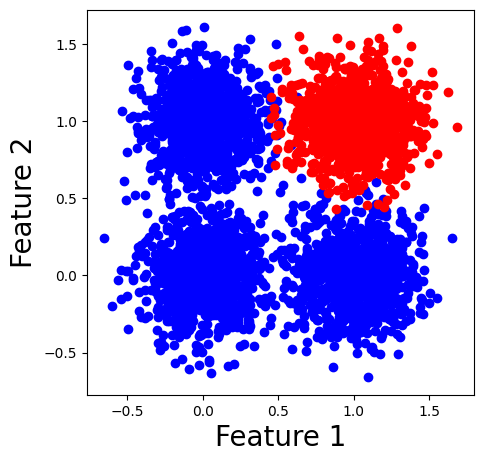

In [22]:
# Ejemplo de visualización de datos en 2 dimensiones
import numpy as np

# Definimos desviación estándar para las clases
Desvio = 0.2 # --> Dispersión de las clases
N = 20       # -->  Numero de iteraciones

A = np.random.randn(2,1000)*Desvio
B = np.random.randn(1,1000)*Desvio+1
B1 = np.random.randn(1,1000)*Desvio
C = np.random.randn(1,1000)*Desvio
C1 = np.random.randn(1,1000)*Desvio+1
D = np.random.randn(2,1000)*Desvio+1

X = np.concatenate((A,np.concatenate((B,B1)),np.concatenate((C,C1)),D),axis=1)
y = np.concatenate((np.zeros((1,3000)),np.ones((1,1000))),axis=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.scatter(X[0,:3000],X[1,:3000], color='b')
plt.scatter(X[0,3000:],X[1,3000:], color='r')
plt.xlabel('Feature 1', fontsize=20)
plt.ylabel('Feature 2', fontsize=20)



In [19]:
X.shape

(2, 4000)

Text(0, 0.5, 'Feature 2')

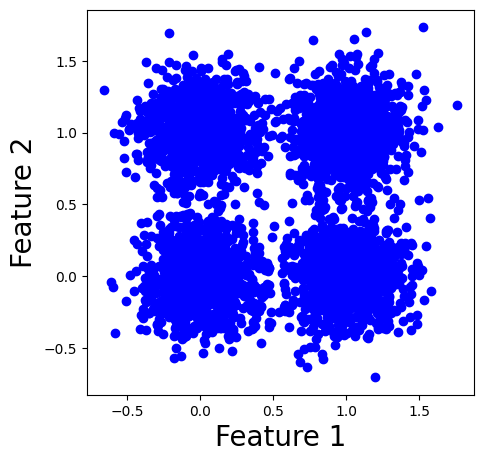

In [20]:
plt.figure(figsize=(5,5))
plt.scatter(X[0,:],X[1,:], color='b')
plt.xlabel('Feature 1', fontsize=20)
plt.ylabel('Feature 2', fontsize=20)

In [27]:
X = X.T
X.shape

(4000, 2)

**¿Cuántos grupos (clústeres) hay?** ----> **<font color=red>¡Pregunta a resolver!</font>**

**<font color=red>Aspectos importantes</font>**

1. ¿Qué características usar?
2. ¿Qué medidas de similitud usar?
3. ¿Qué método o algoritmo usar?
4. ¿Cuantos grupos se deben formar?
5. ¿Cómo asignar las filas (o columnas) a las agrupaciones?
6. ¿Cómo validar las agrupaciones que se han formado?

---
**<font color=red>Procedimiento</font>**

**1. Inspección Visual**

**2. Algoritmo a usar**
* Jerárquico:
 * Aglomerativos (*Linkage*)
 * Divisivos
* Partición
 * K-means
* Basados en Densidad
 * DBSCAN
* Otros Métodos
 * Redes Neuronales: SOM - ART - Otros

**3. Medidas de Similitud:**

* Distancia Intra-cluster
* Distancia Inter-clusters

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2019/08/Screenshot-from-2019-08-08-15-37-02.png">

Medidas:
* Distancia **Euclidiana**

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTEHNfR_IkZIgUt2F40gjTcOCh8eVNnFUloVg&usqp=CAU">

* Distancia **Mahalanobis**

<img src="https://www.researchgate.net/profile/Chul-Woo-Kim/publication/275701517/figure/fig7/AS:668639590088740@1536427509947/Concept-of-Mahalanobis-distance-MD.png" width=500>


---


## **Métodos Aglomerativos: Algoritmo *Linkage***

La agrupación aglomerativa es un conjunto de algoritmos basados ​​en la misma idea. La idea fundamental es comenzar con cada punto de su propio clúster y, para cada uno, usar un criterio para elegir otro clúster con el que fusionarse.

### ***Linkage***

La versión más básica es el algoritmo *linkage* (enlace simple), que elige el clúster más cercano para fusionar, lo que permite clasificar el árbol por distancia, según el momento en que se fusionaron o dividieron los clústeres.



El algortimo ***Linkage*** puede ser empleado de la librería ```Scipy``` para la computación científica y matemática. Enlace [aquí](https://scipy.org/)

<img src="https://media.licdn.com/dms/image/v2/D4D12AQELmHDR85Un1Q/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1683096619215?e=2147483647&v=beta&t=YdjkdiEFLFimO6oaSxjWeyHY488VuiM__K0OeH1vHbs" width=300>

**Podemos aplicar el algoritmo <font color=red>*Linkage*</font> sobre los datos de $2$ características (*features*) del ejemplo de los puntos azules:**

In [29]:
from scipy.cluster.hierarchy import linkage
row_clusters1 = linkage(X/X.max(), method='complete', metric='euclidean')
row_clusters1

array([[3.30000000e+01, 7.00000000e+01, 1.07814302e-04, 2.00000000e+00],
       [3.15700000e+03, 3.47700000e+03, 1.44800340e-04, 2.00000000e+00],
       [3.14000000e+02, 3.29000000e+02, 1.59491744e-04, 2.00000000e+00],
       ...,
       [7.99000000e+03, 7.99200000e+03, 1.31929612e+00, 1.86200000e+03],
       [7.99300000e+03, 7.99500000e+03, 1.36786151e+00, 2.13800000e+03],
       [7.99600000e+03, 7.99700000e+03, 1.57027696e+00, 4.00000000e+03]])

In [30]:
pd.DataFrame(row_clusters1, columns=['row label 1', 'row label 2', 'distance', 'no. of items in clust.'], index=[f'cluster {(i + 1)}'
                                                                                                                for i in range(row_clusters1.shape[0])])

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,33.0,70.0,0.000108,2.0
cluster 2,3157.0,3477.0,0.000145,2.0
cluster 3,314.0,329.0,0.000159,2.0
cluster 4,2553.0,2726.0,0.000177,2.0
cluster 5,1552.0,1764.0,0.000195,2.0
...,...,...,...,...
cluster 3995,7980.0,7987.0,0.869319,699.0
cluster 3996,7991.0,7994.0,0.954630,1195.0
cluster 3997,7990.0,7992.0,1.319296,1862.0
cluster 3998,7993.0,7995.0,1.367862,2138.0


(array([2.196e+03, 8.310e+02, 3.560e+02, 1.770e+02, 1.040e+02, 6.900e+01,
        5.900e+01, 3.100e+01, 3.300e+01, 2.200e+01, 1.300e+01, 1.400e+01,
        1.000e+01, 9.000e+00, 1.000e+01, 7.000e+00, 4.000e+00, 6.000e+00,
        6.000e+00, 2.000e+00, 4.000e+00, 0.000e+00, 2.000e+00, 2.000e+00,
        4.000e+00, 1.000e+00, 4.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 3.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

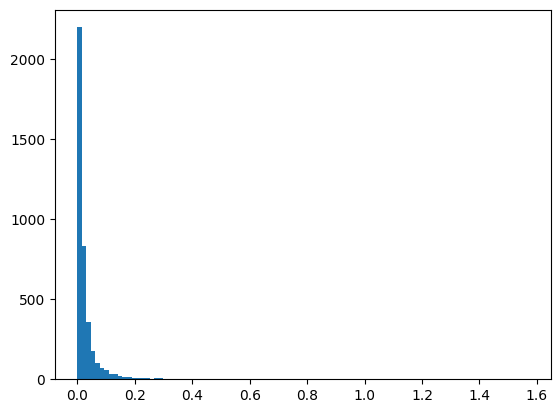

In [32]:
plt.hist(row_clusters1[:,2], bins=100)

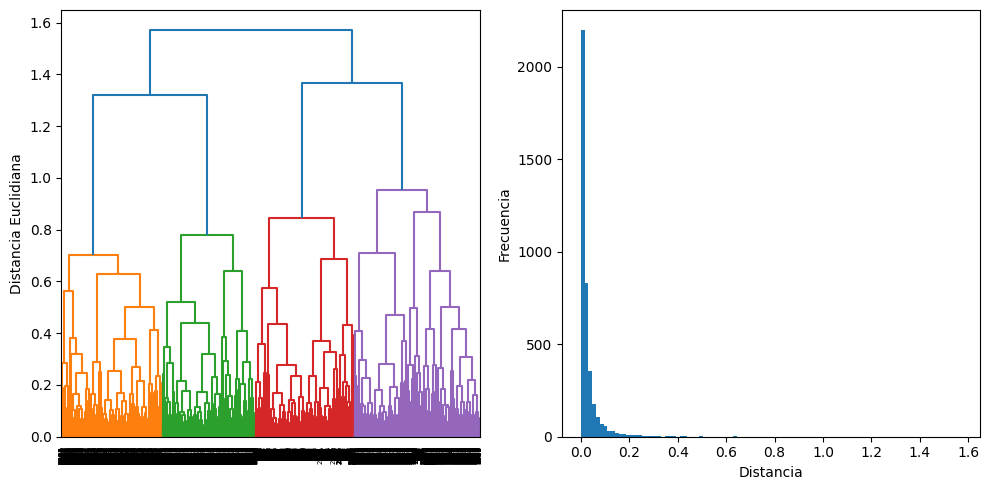

In [37]:
from scipy.cluster.hierarchy import dendrogram

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

row_dendr = dendrogram(row_clusters1, ax=axes[0]) # Plot dendrogram on the first subplot
axes[0].set_ylabel('Distancia Euclidiana')

# plt.subplot(1,2,2) is no longer needed as we use axes[1]
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlabel('Distancia')
axes[1].hist(row_clusters1[:,2], bins=100)

plt.tight_layout() # Call tight_layout after all plots have been made
plt.show()

In [38]:
# Análisis de fclusterdata para agrupamiento basado en distancias
from scipy.cluster.hierarchy import fclusterdata
clusters = fclusterdata(X/X.max(), 0.0895 , criterion='distance')
np.unique(clusters)

array([1, 2, 3, 4, 5], dtype=int32)

## **Métodos Basados en Partición: Algoritmo de *K-means***

Pasos:

1. Seleccionar los centroides iniciales de los *K* clústeres.
2. Asignar cada observación al clúster C(k) cuyo centroide está más cerca.
3. Recalcular su centroide basado en los
elementos que están contenidos en el clúster.
4. Ir al paso 2 hasta que se consiga convergencia

<img src="https://databricks.com/wp-content/uploads/2015/01/image04.gif" width=300>

In [39]:
X.shape

(4000, 2)

Text(341.5, 0.5, 'Feature 2')

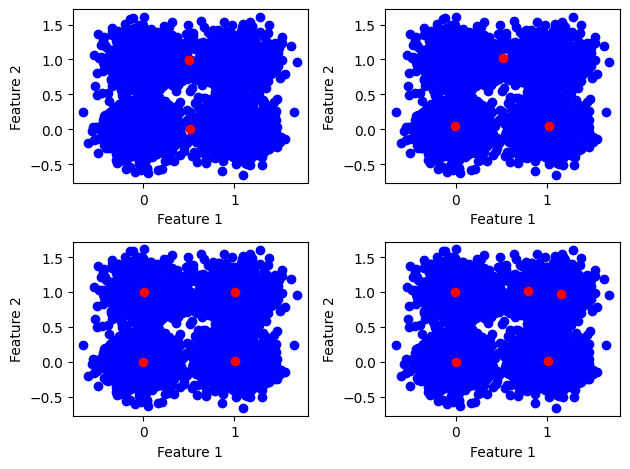

In [40]:
#X = X.T
from sklearn.cluster import KMeans
# K=2
kmeans = KMeans(n_clusters=2, max_iter=2000,random_state=10).fit(X)
K2 = kmeans.cluster_centers_
plt.subplot(2,2,1)
plt.scatter(X.T[0,:],X.T[1,:], color='b')
plt.scatter(K2[:,0],K2[:,1], color='r')
plt.tight_layout()
plt.xlabel('Feature 1', fontsize=10)
plt.ylabel('Feature 2', fontsize=10)
# K=3
kmeans = KMeans(n_clusters=3, max_iter=2000,random_state=10).fit(X)
K3 = kmeans.cluster_centers_
plt.subplot(2,2,2)
plt.scatter(X.T[0,:],X.T[1,:], color='b')
plt.scatter(K3[:,0],K3[:,1], color='r')
plt.tight_layout()
plt.xlabel('Feature 1', fontsize=10)
plt.ylabel('Feature 2', fontsize=10)
# K=4
kmeans = KMeans(n_clusters=4, max_iter=2000,random_state=10).fit(X)
K4 = kmeans.cluster_centers_
plt.subplot(2,2,3)
plt.scatter(X.T[0,:],X.T[1,:], color='b')
plt.scatter(K4[:,0],K4[:,1], color='r')
plt.tight_layout()
plt.xlabel('Feature 1', fontsize=10)
plt.ylabel('Feature 2', fontsize=10)
# K=5
kmeans = KMeans(n_clusters=5, max_iter=2000,random_state=10).fit(X)
K5 = kmeans.cluster_centers_
plt.subplot(2,2,4)
plt.scatter(X.T[0,:],X.T[1,:], color='b')
plt.scatter(K5[:,0],K5[:,1], color='r')
plt.tight_layout()
plt.xlabel('Feature 1', fontsize=10)
plt.ylabel('Feature 2', fontsize=10)

## **Métodos Basados en Densidad: DBSCAN**

El DBSCAN es un algoritmo **no supervisado** muy conocido en materia de ***Clustering***. Fue presentado en 1996 por Martin Ester, Hans-Peter Kriegel, Jörg Sander y Xiawei Xu.

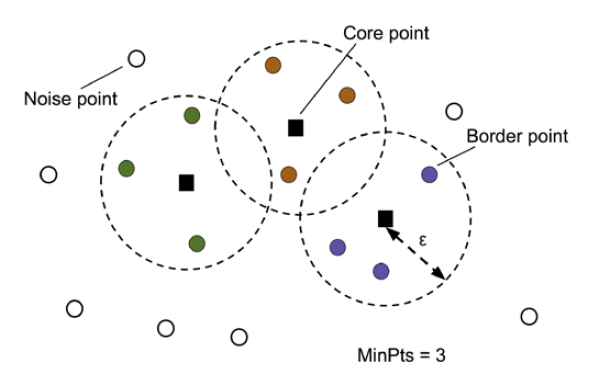

El **DBSCAN** es un algoritmo sencillo que define los clústeres mediante la estimación de la densidad local. Se puede dividir en 4 etapas:

1.  Para cada observación miramos el número de puntos a una distancia máxima ε de ella. Esta zona se denomina **ε-vecindad** de la observación.
2. Si una observación tiene al menos un cierto número de vecinos, incluida ella misma, se considera una observación central. En este caso, se ha detectado una observación de alta densidad.
3. Todas las **observaciones** en la vecindad de una **observación central** pertenecen al mismo clúster. Puede haber observaciones centrales cercanas entre sí. Por lo tanto, de un paso a otro, se obtiene una larga secuencia de observaciones centrales que constituyen un único clúster.
4. Cualquier observación que no sea una observación central y que no tenga ninguna observación central en su vecindad se considera una **anomalía**.

**Hiperparámetros:**

* **ε-vecindad:** eps
* **Número mínimo de vecinos:** min_samples

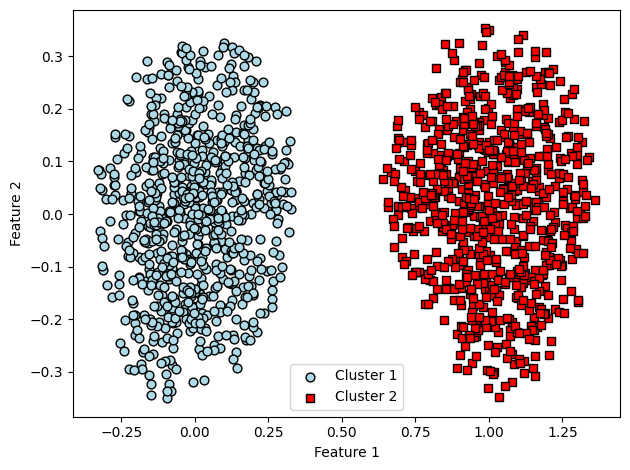

In [41]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.125, min_samples=100, metric='euclidean')
y_db = db.fit_predict(X)
plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1], c='lightblue', edgecolor='black', marker='o', s=40, label='Cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1], c='red', edgecolor='black', marker='s', s=40, label='Cluster 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Grupos')

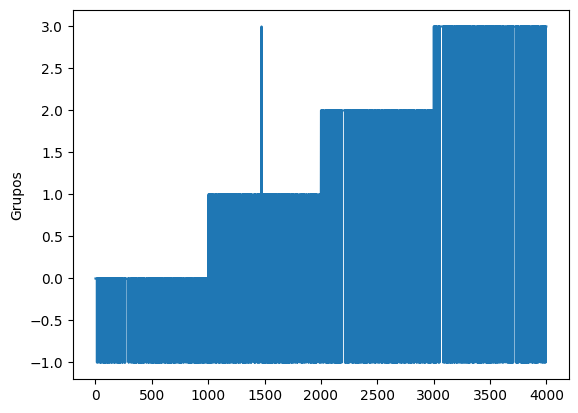

In [42]:
plt.plot(y_db)
plt.ylabel('Grupos')

In [43]:
np.unique(y_db)

array([-1,  0,  1,  2,  3])

## **<font color=red>Validación del Agrupamiento</font>**

**Medidas de Calidad de Agrupamiento**

Ver [aquí](https://gdcoder.com/silhouette-analysis-vs-elbow-method-vs-davies-bouldin-index-selecting-the-optimal-number-of-clusters-for-kmeans-clustering/) más detalles:

* Índice **Davies-Bouldin**

<img src="https://he-s3.s3.amazonaws.com/media/uploads/26938da.png" width=250>

* Índice **Silueta**

$a(i)=\frac{1}{|C_{i}|-1}\sum_{j \in C_{i},i \neq j}d(i,j)$

$b(i)=min_{k \neq i} \frac{1}{|C_{i}|}\sum_{j \in C_{k}}d(i,j)$

$s(i)=\frac{b(i)-a(i)}{max(a(i),b(i))}$

* -1 ≦ s(i) ≦1
* Si s(i) ≈ 1, el punto está en el cluster correcto; pertenece más a su cluster que al vecino.
* Si s(i) ≈ -1, el punto es del cluster vecino; es más cercano a su vecino que al propio cluster.
* Si s(i) = 0 entonces |Ci | = 1.
* Si s(i) ≈ 0, el punto podría ser de otro cluster.




### **Evaluamos la Calidad de Agrupamiento con *K-Means***

In [ ]:
# Ejemplo uso de K-means

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score,silhouette_score,silhouette_samples
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Realizamos el agrupamiento de los datos vistos arriba

#X = np.transpose(X) # Filas: Instancias - Columnas: Variables

sse,db,slc = {}, {}, {}
for k in range(2, 10):
    # semilla de 10 para reproducibilidad de resultados.
    kmeans = KMeans(n_clusters=k, max_iter=2000,random_state=10).fit(X)
    #if k == 3: labels = kmeans.labels_
    clusters = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    db[k] = davies_bouldin_score(X,clusters)
    slc[k] = silhouette_score(X,clusters)

In [ ]:
db

{2: np.float64(1.096092644424639),
 3: np.float64(0.7045518981048419),
 4: np.float64(0.5025003029238609),
 5: np.float64(0.8112545486040765),
 6: np.float64(0.993329033764654),
 7: np.float64(1.1225551779645688),
 8: np.float64(1.0312799623359887),
 9: np.float64(1.114506085607561)}

**Método del Codo (Elbow)**

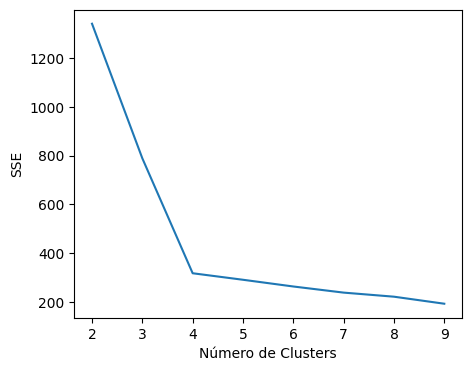

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Número de Clusters")
plt.ylabel("SSE")
plt.show()

**Índice Davies-Bouldin**

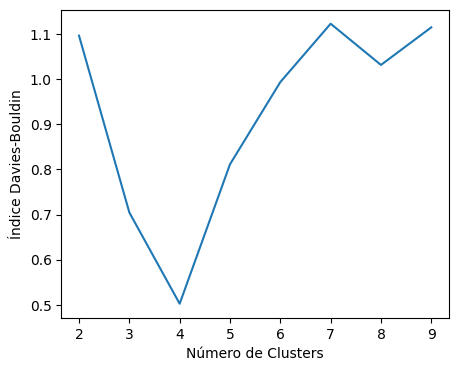

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("Número de Clusters")
plt.ylabel("Índice Davies-Bouldin")
plt.show()

**Índice Silueta**

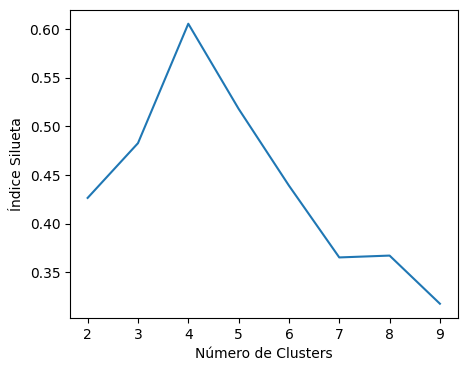

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("Número de Clusters")
plt.ylabel("Índice Silueta")
plt.show()

### **Evaluamos la Calidad de Agrupamiento con *Linkage***

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
row_clusters = linkage(X, method='complete', metric='euclidean')

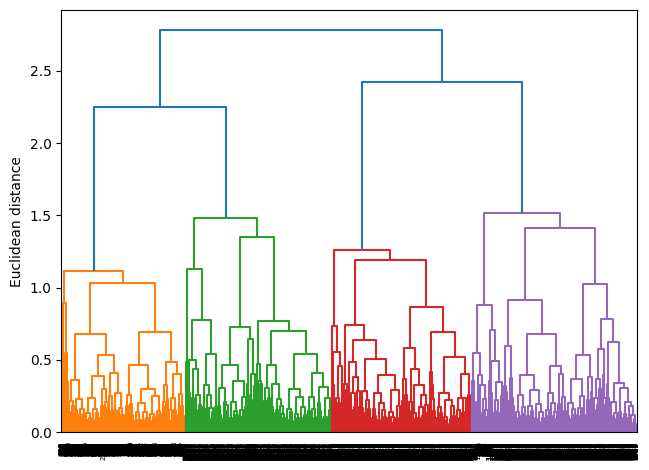

In [ ]:
row_dendr = dendrogram(row_clusters)#, labels=labels)
plt.tight_layout()
plt.ylabel('Euclidean distance')
plt.show()

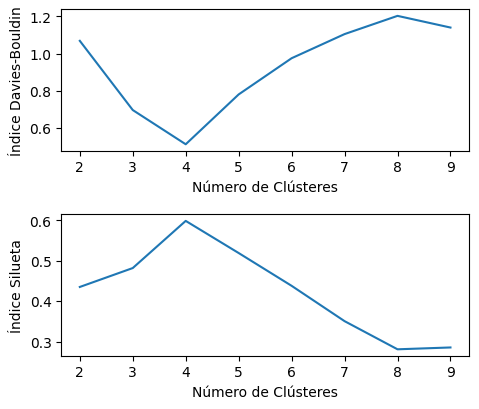

In [ ]:
from sklearn.cluster import AgglomerativeClustering

db_links,slc_links = {}, {}
for n in range(2,10):
  clustering = AgglomerativeClustering(n_clusters=n).fit(X)
  y_pred = clustering.labels_
  db_links[n] = davies_bouldin_score(X,y_pred)
  slc_links[n] = silhouette_score(X,y_pred)

plt.figure(figsize=(5,4))
plt.subplot(2,1,1)
plt.plot(list(db_links.keys()), list(db_links.values())) #
plt.xlabel("Número de Clústeres")
plt.ylabel("Índice Davies-Bouldin")
plt.subplot(2,1,2)
plt.tight_layout()
plt.plot(list(slc_links.keys()), list(slc_links.values())) #
plt.xlabel("Número de Clústeres")
plt.ylabel("Índice Silueta")
plt.show()

In [ ]:
# Análisis de grupos con índice Davies Bouldin
db_link, slc_link = {}, {}
dis = np.arange(0.0750, 0.091, 0.0005)
for n in range(dis.shape[0]):
  clusters = fclusterdata(X/X.max(), dis[n] , criterion='distance')
  db_link[n] = davies_bouldin_score(X,clusters)
  slc_link[n] = silhouette_score(X,clusters)
  #print(dis[n],np.unique(clusters),db_link,slc_link)

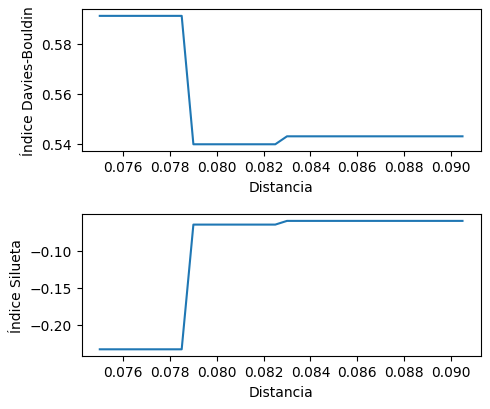

In [ ]:
plt.figure(figsize=(5,4))
plt.subplot(2,1,1)
plt.plot(dis, list(db_link.values()))
plt.xlabel("Distancia")
plt.ylabel("Índice Davies-Bouldin")
plt.subplot(2,1,2)
plt.tight_layout()
plt.plot(dis, list(slc_link.values()))
plt.xlabel("Distancia")
plt.ylabel("Índice Silueta")
plt.show()

### **Evaluamos la Calidad de Agrupamiento con DBSCAN**

In [ ]:
X.shape

(4000, 2)

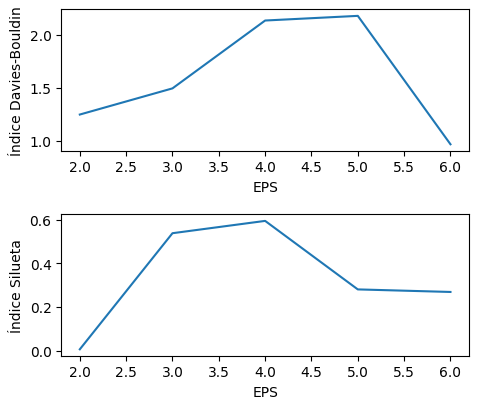

In [ ]:
#X = X.T
sse,db,slc = {}, {}, {}
epss = list()
for e in range(1, 11):
    dbscan = DBSCAN(eps=e/20, min_samples=100, metric='euclidean')
    y_db = dbscan.fit_predict(X)
    y_db = y_db + 1
    n_clusters = len(np.unique(y_db))
    epss.append([e/20,n_clusters])
    if n_clusters > 1:
        db[e] = davies_bouldin_score(X,y_db)
        slc[e] = silhouette_score(X,y_db)
    else:
        db[e] = np.nan
        slc[e] = np.nan


plt.figure(figsize=(5,4))
plt.subplot(2,1,1)
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("EPS")
plt.ylabel("Índice Davies-Bouldin")
plt.subplot(2,1,2)
plt.tight_layout()
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("EPS")
plt.ylabel("Índice Silueta")
plt.show()

In [ ]:
epss

[[0.05, 1],
 [0.1, 5],
 [0.15, 5],
 [0.2, 5],
 [0.25, 2],
 [0.3, 2],
 [0.35, 1],
 [0.4, 1],
 [0.45, 1],
 [0.5, 1]]

In [ ]:
np.array(epss)[:,0].T

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ])

In [ ]:
#pd.DataFrame([epss, db.values, slc.values], columns = ['eps','clusters','db','slc'])
pd.DataFrame([np.array(epss)[:,0], np.array(epss)[:,1], db.values(), slc.values()], index = ['eps','clusters','db','slc']).T

,eps,clusters,db,slc
0,0.05,1.0,NaN,NaN
1,0.10,5.0,1.248588,0.008842
2,0.15,5.0,1.494588,0.537904
3,0.20,5.0,2.132533,0.594027
4,0.25,2.0,2.176290,0.281807
5,0.30,2.0,0.969075,0.270164
6,0.35,1.0,NaN,NaN
7,0.40,1.0,NaN,NaN
8,0.45,1.0,NaN,NaN
9,0.50,1.0,NaN,NaN


# **Ejercicio**:

Realice un agrupamiento y análisis de clústeres de los datos de la base de datos de Diabetes.

Ejemplo: [Diabetes](https://www.kaggle.com/datasets/mathchi/diabetes-data-set)

In [1]:
!curl -L -o /content/diabetes-data-set.zip\
  https://www.kaggle.com/api/v1/datasets/download/mathchi/diabetes-data-set

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  9128  100  9128    0     0  38479      0 --:--:-- --:--:-- --:--:-- 38479


In [2]:
# Descomprimimos el archivo
!unzip /content/diabetes-data-set.zip

Archive:  /content/diabetes-data-set.zip
  inflating: diabetes.csv            


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_csv("/content/diabetes.csv")
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
dataset.shape

(768, 9)

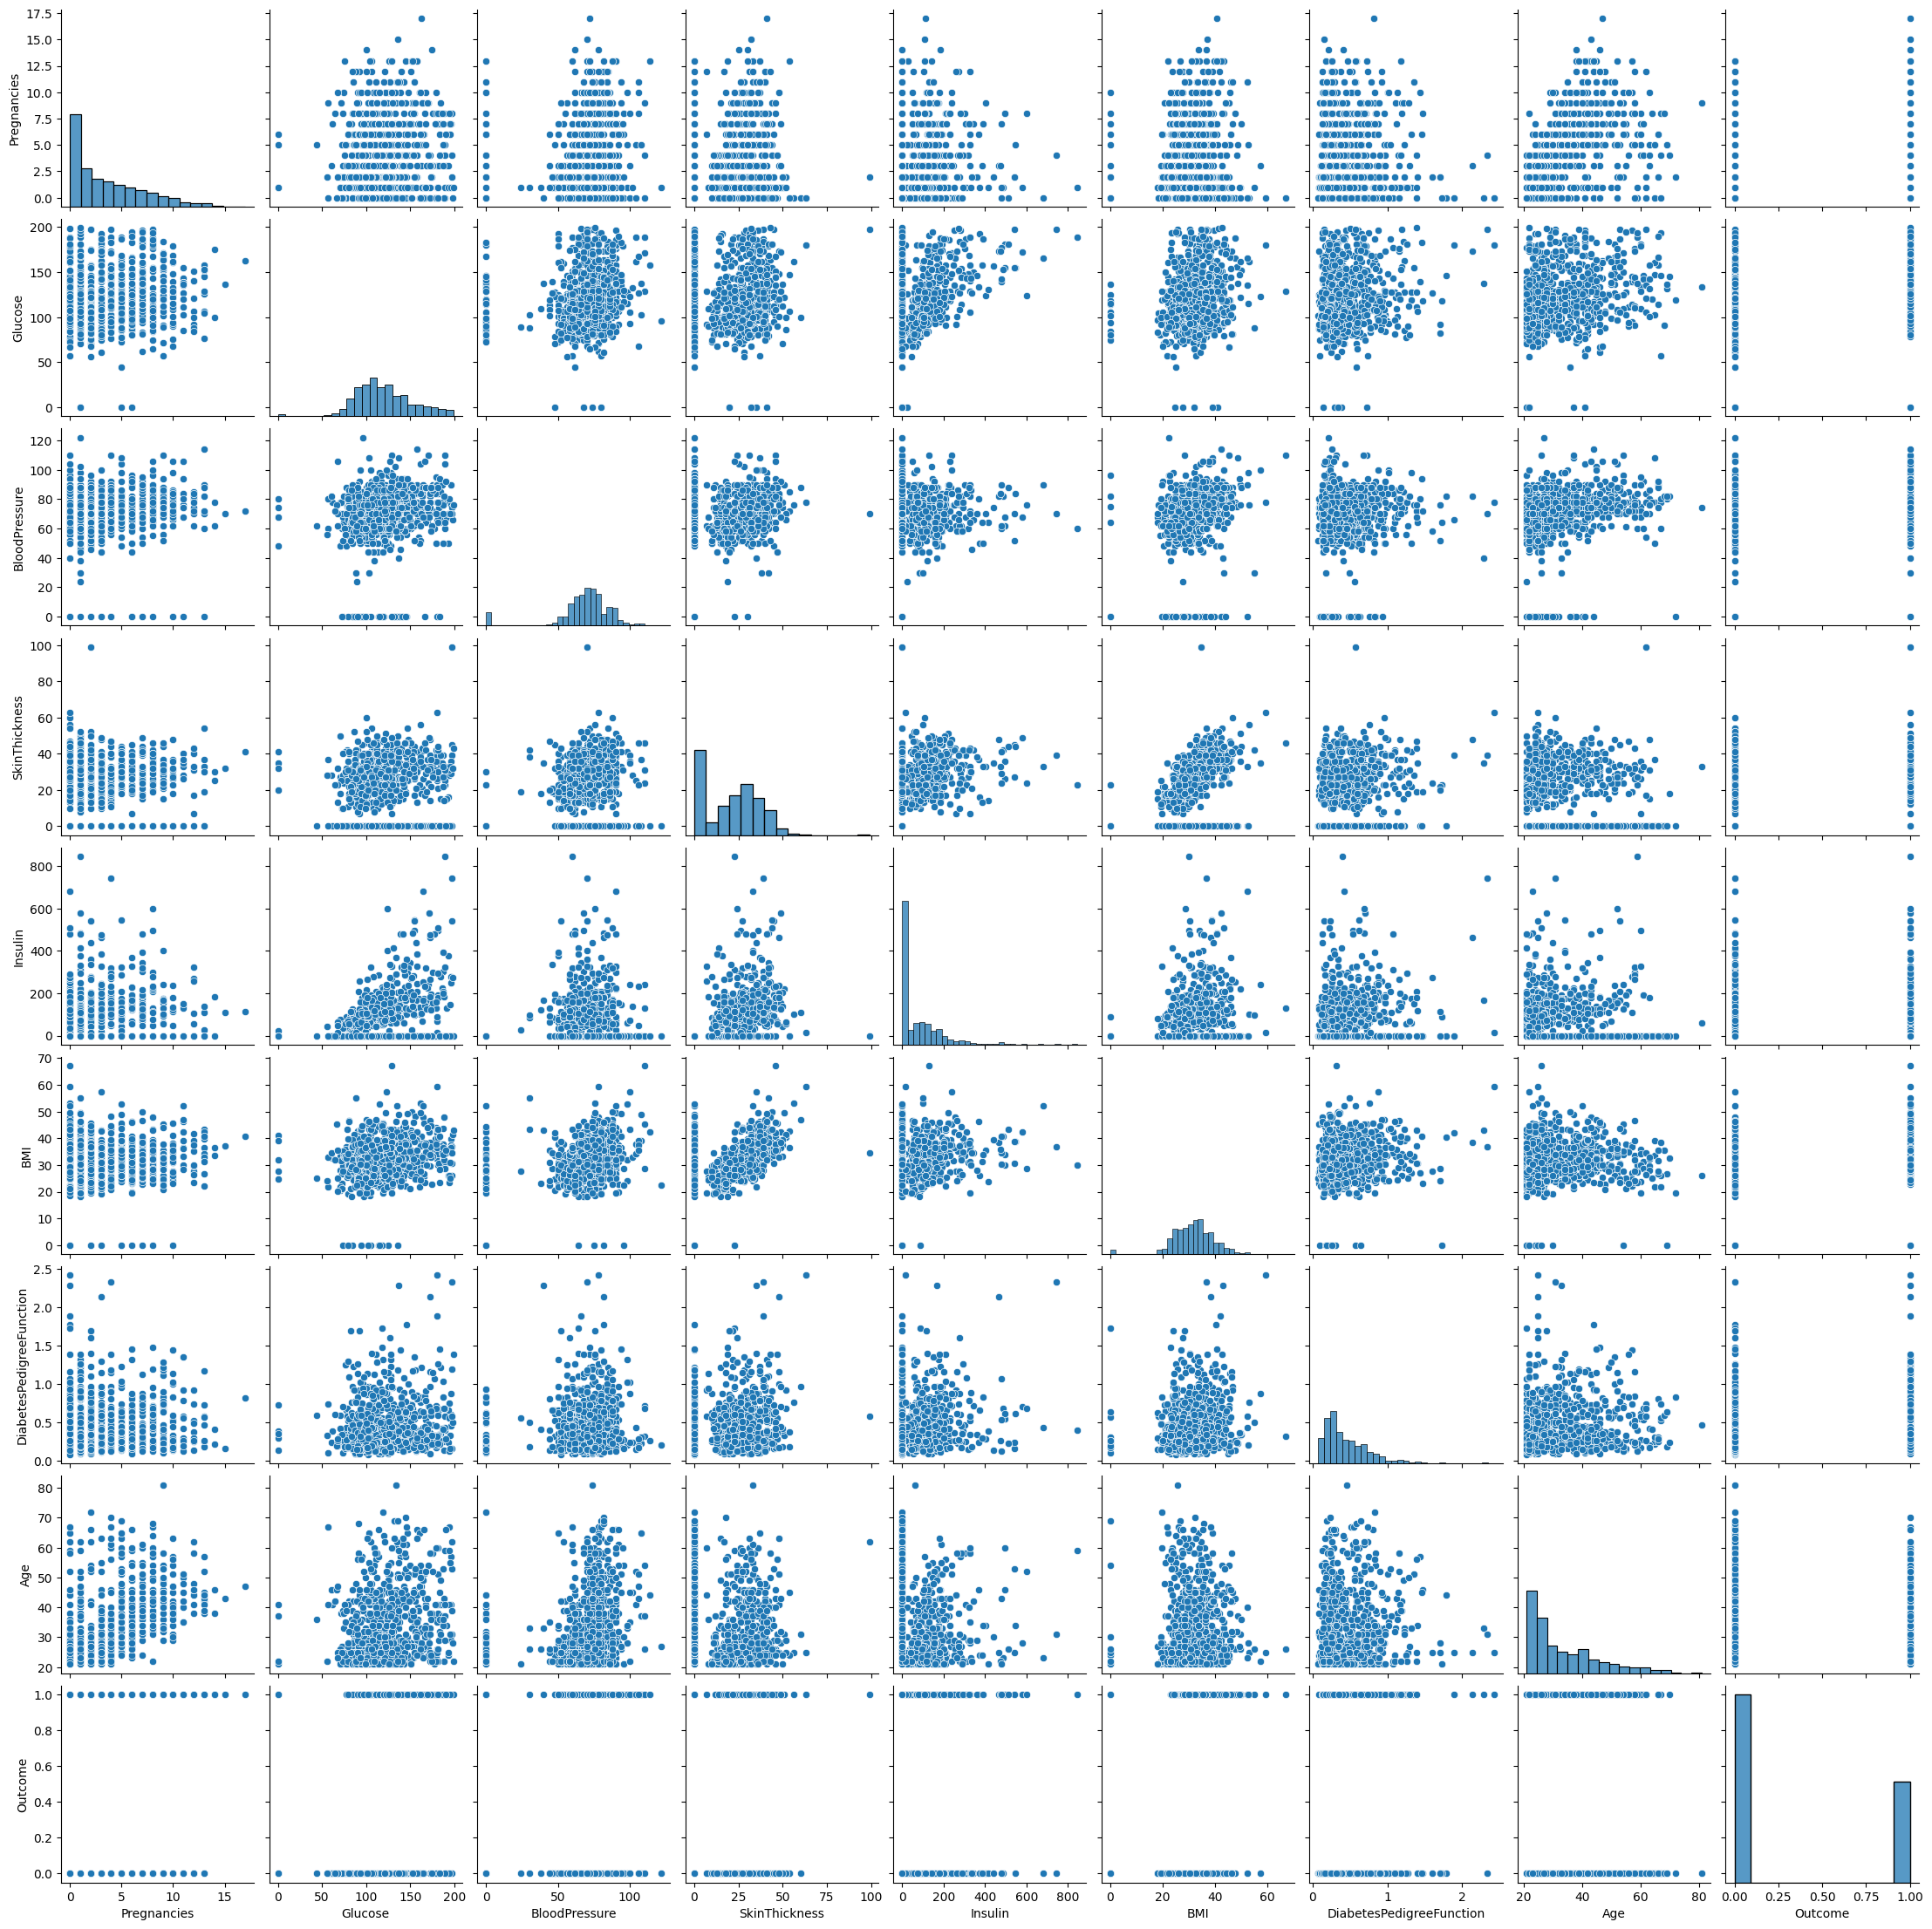

In [6]:
import seaborn as sns
F = pd.DataFrame(dataset)
sns.pairplot(F)

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score,silhouette_score,silhouette_samples

X = dataset.iloc[:,:-1]/np.max(dataset.iloc[:,:-1], axis=0)
#X.describe()

sse,db,slc = {}, {}, {}
for k in range(2, 10):
    # semilla de 10 para reproducibilidad de resultados.
    kmeans = KMeans(n_clusters=k, max_iter=2000,random_state=10).fit(X)
    clusters = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    db[k] = davies_bouldin_score(X,clusters)
    slc[k] = silhouette_score(X,clusters)

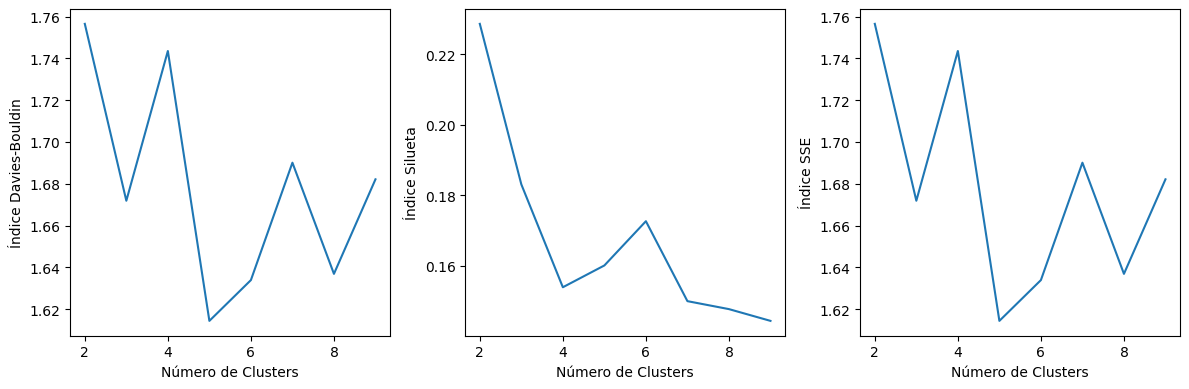

In [17]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("Número de Clusters")
plt.ylabel("Índice Davies-Bouldin")
plt.subplot(1,3,2)
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("Número de Clusters")
plt.ylabel("Índice Silueta")
plt.subplot(1,3,3)
plt.plot(list(sse.keys()), list(db.values()))
plt.xlabel("Número de Clusters")
plt.ylabel("Índice SSE")
plt.tight_layout()